**Prática de Suavização de Imagens**

(filtro passa baixa)

Exercícios retirados de:
http://homepages.inf.ed.ac.uk/rbf/HIPR2/mean.htm

http://homepages.inf.ed.ac.uk/rbf/HIPR2/gsmooth.htm

http://homepages.inf.ed.ac.uk/rbf/HIPR2/median.htm

1)	Aplique o filtro de Média na imagem abaixo para diferentes tamanhos de máscaras.
- 3x3; 7x7; 3x3 aplicado três vezes sequenciais.

In [5]:
from google.colab import files
uploaded = files.upload()          # selecione sta2.png
IMAGE_PATH = list(uploaded.keys())[0]


Saving download (1).png to download (1).png
Arquivo carregado: download (1).png


In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter


Dimensões : (418, 320)
dtype     : uint8


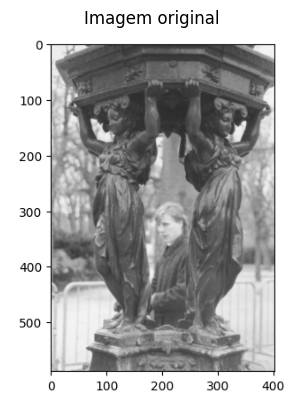

In [6]:
img = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)

gray = img.astype(np.float64)

print(f"Dimensões : {img.shape}")
print(f"dtype     : {img.dtype}")

plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title("Imagem original")
plt.axis("off")
plt.show()


In [7]:
mean_3x3 = uniform_filter(gray, size=3)

mean_7x7 = uniform_filter(gray, size=7)

mean_3x3_pass1 = uniform_filter(gray,          size=3)
mean_3x3_pass2 = uniform_filter(mean_3x3_pass1, size=3)
mean_3x3_pass3 = uniform_filter(mean_3x3_pass2, size=3)

print("Filtros calculados.")
print(f"  3x3 (1x)  — valor médio global: {mean_3x3.mean():.2f}  std: {mean_3x3.std():.2f}")
print(f"  7x7 (1x)  — valor médio global: {mean_7x7.mean():.2f}  std: {mean_7x7.std():.2f}")
print(f"  3x3 (3x)  — valor médio global: {mean_3x3_pass3.mean():.2f}  std: {mean_3x3_pass3.std():.2f}")


Filtros calculados.
  3x3 (1x)  — valor médio global: 164.57  std: 70.89
  7x7 (1x)  — valor médio global: 164.57  std: 68.27
  3x3 (3x)  — valor médio global: 164.57  std: 69.36


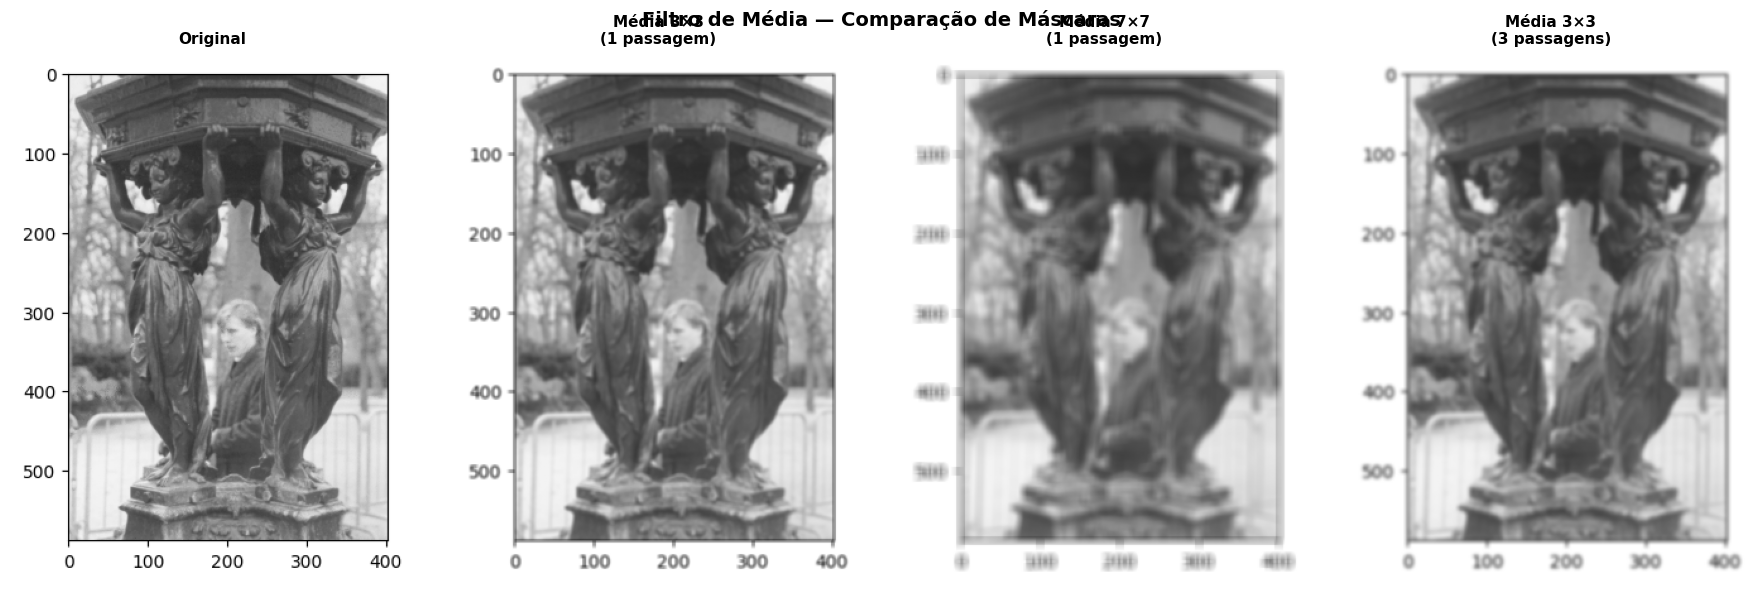

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 6))
fig.suptitle("Filtro de Média — Comparação de Máscaras", fontsize=14, fontweight="bold")

panels = [
    (gray,           "Original"),
    (mean_3x3,       "Média 3×3\n(1 passagem)"),
    (mean_7x7,       "Média 7×7\n(1 passagem)"),
    (mean_3x3_pass3, "Média 3×3\n(3 passagens)"),
]

for ax, (data, title) in zip(axes, panels):
    ax.imshow(data, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=8)
    ax.axis("off")

plt.tight_layout()
plt.show()


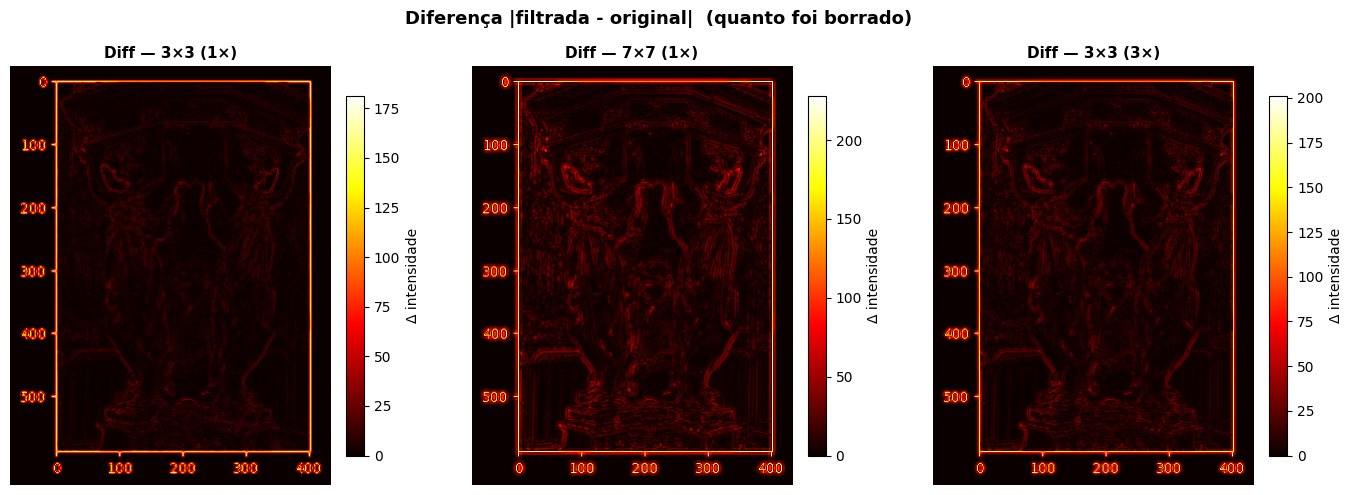

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Diferença |filtrada - original|  (quanto foi borrado)", fontsize=13, fontweight="bold")

diffs = [
    (np.abs(mean_3x3       - gray), "Diff — 3×3 (1×)"),
    (np.abs(mean_7x7       - gray), "Diff — 7×7 (1×)"),
    (np.abs(mean_3x3_pass3 - gray), "Diff — 3×3 (3×)"),
]

for ax, (diff, title) in zip(axes, diffs):
    im = ax.imshow(diff, cmap="hot", vmin=0, vmax=diff.max())
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Δ intensidade")

plt.tight_layout()
plt.show()


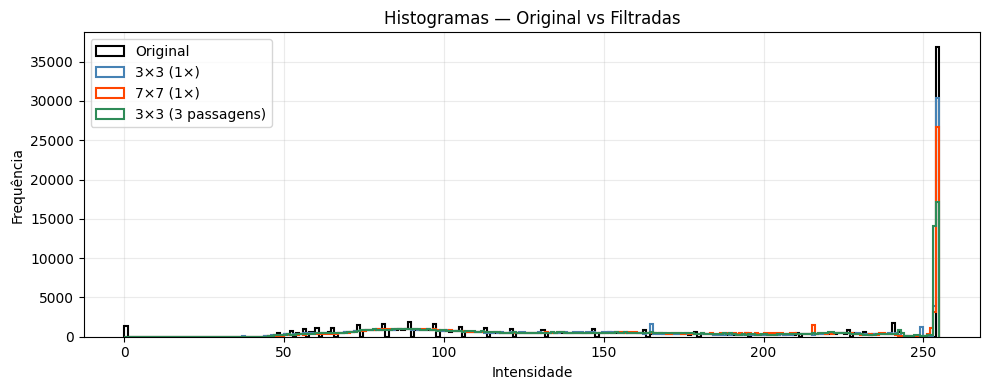

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))

configs = [
    (gray,           "Original",          "black",      1.0),
    (mean_3x3,       "3×3 (1×)",          "steelblue",  1.0),
    (mean_7x7,       "7×7 (1×)",          "orangered",  1.0),
    (mean_3x3_pass3, "3×3 (3 passagens)", "seagreen",   1.0),
]

for data, label, color, alpha in configs:
    ax.hist(data.ravel().astype(np.uint8), bins=256, range=(0, 255),
            histtype="step", color=color, alpha=alpha, linewidth=1.5, label=label)

ax.set_xlabel("Intensidade")
ax.set_ylabel("Frequência")
ax.set_title("Histogramas — Original vs Filtradas")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


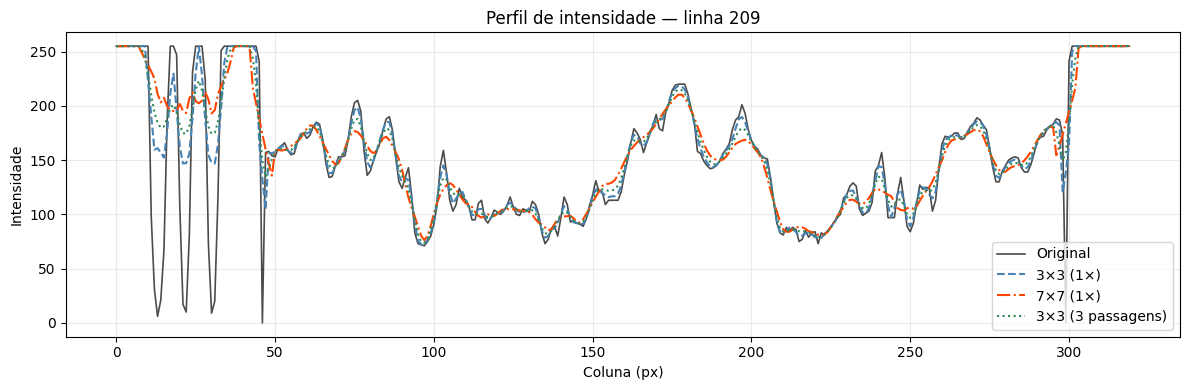

In [11]:
row = gray.shape[0] // 2

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(gray[row],           color="black",     linewidth=1.2, label="Original",          alpha=0.7)
ax.plot(mean_3x3[row],       color="steelblue", linewidth=1.5, label="3×3 (1×)",          linestyle="--")
ax.plot(mean_7x7[row],       color="orangered", linewidth=1.5, label="7×7 (1×)",          linestyle="-.")
ax.plot(mean_3x3_pass3[row], color="seagreen",  linewidth=1.5, label="3×3 (3 passagens)", linestyle=":")
ax.set_xlabel("Coluna (px)")
ax.set_ylabel("Intensidade")
ax.set_title(f"Perfil de intensidade — linha {row}")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


2)	Aplique o filtro Gaussiano à imagem abaixo para diferentes valores de desvio padrão (σ) e tamanho de máscara.
- σ = 1.0 (kernel size 5×5).	σ = 2.0 (kernel size 9×9).	σ =  4.0 (kernel size 15×15).

In [12]:
from google.colab import files
uploaded = files.upload()
IMAGE_PATH = list(uploaded.keys())[0]


Saving download (2).png to download (2).png


In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


Dimensoes : (418, 300)
dtype     : uint8


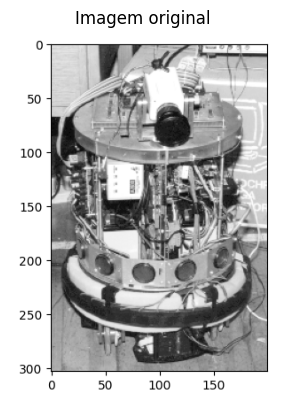

In [14]:
img = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)

print(f"Dimensoes : {img.shape}")
print(f"dtype     : {img.dtype}")

plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title("Imagem original")
plt.axis("off")
plt.show()


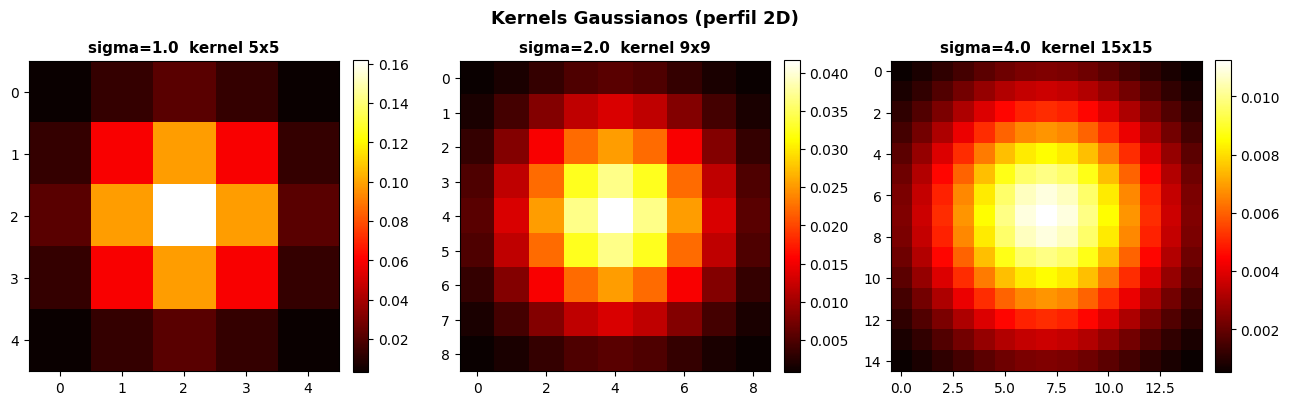

In [15]:
configs = [(1.0, 5), (2.0, 9), (4.0, 15)]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("Kernels Gaussianos (perfil 2D)", fontsize=13, fontweight="bold")

for ax, (sigma, k) in zip(axes, configs):
    kernel_1d = cv2.getGaussianKernel(k, sigma)
    kernel_2d = np.outer(kernel_1d, kernel_1d)

    im = ax.imshow(kernel_2d, cmap="hot")
    ax.set_title(f"sigma={sigma}  kernel {k}x{k}", fontsize=11, fontweight="bold")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


In [16]:
gauss_1_5  = cv2.GaussianBlur(img, (5,  5),  1.0)   # sigma=1.0, 5x5
gauss_2_9  = cv2.GaussianBlur(img, (9,  9),  2.0)   # sigma=2.0, 9x9
gauss_4_15 = cv2.GaussianBlur(img, (15, 15), 4.0)   # sigma=4.0, 15x15

for name, filt in [("sigma=1.0 (5x5)", gauss_1_5),
                   ("sigma=2.0 (9x9)", gauss_2_9),
                   ("sigma=4.0 (15x15)", gauss_4_15)]:
    diff = np.abs(img.astype(np.float32) - filt.astype(np.float32))
    print(f"{name:20s}  media={filt.mean():.2f}  std={filt.std():.2f}  diff_max={diff.max():.1f}")


sigma=1.0 (5x5)       media=173.78  std=68.90  diff_max=168.0
sigma=2.0 (9x9)       media=173.79  std=65.22  diff_max=212.0
sigma=4.0 (15x15)     media=173.79  std=60.78  diff_max=225.0


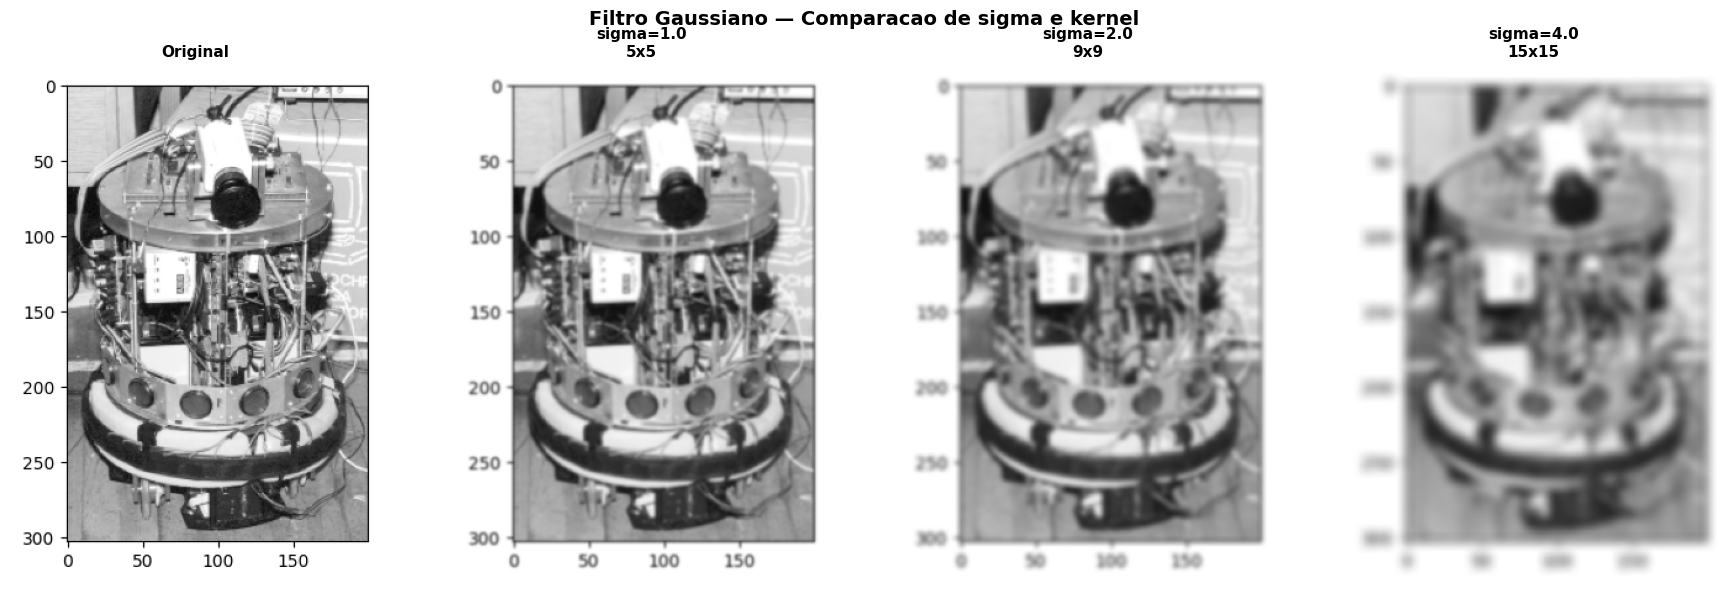

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(18, 6))
fig.suptitle("Filtro Gaussiano — Comparacao de sigma e kernel", fontsize=14, fontweight="bold")

panels = [
    (img,        "Original"),
    (gauss_1_5,  "sigma=1.0\n5x5"),
    (gauss_2_9,  "sigma=2.0\n9x9"),
    (gauss_4_15, "sigma=4.0\n15x15"),
]

for ax, (data, title) in zip(axes, panels):
    ax.imshow(data, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=8)
    ax.axis("off")

plt.tight_layout()
plt.show()


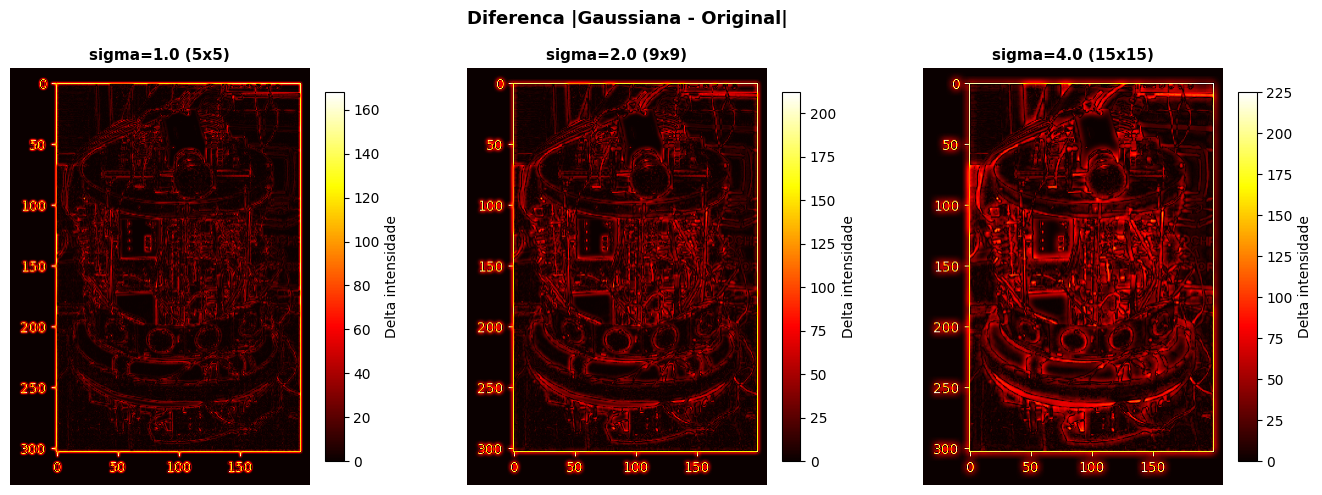

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Diferenca |Gaussiana - Original|", fontsize=13, fontweight="bold")

diffs = [
    (gauss_1_5,  "sigma=1.0 (5x5)"),
    (gauss_2_9,  "sigma=2.0 (9x9)"),
    (gauss_4_15, "sigma=4.0 (15x15)"),
]

for ax, (filt, title) in zip(axes, diffs):
    diff = np.abs(img.astype(np.float32) - filt.astype(np.float32))
    im   = ax.imshow(diff, cmap="hot", vmin=0)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Delta intensidade")

plt.tight_layout()
plt.show()


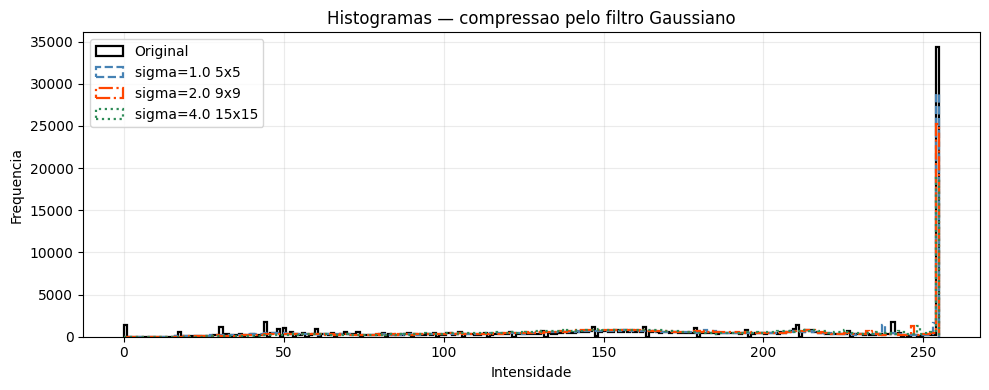

In [19]:
fig, ax = plt.subplots(figsize=(10, 4))

for data, label, color, ls in [
    (img,        "Original",       "black",     "-"),
    (gauss_1_5,  "sigma=1.0 5x5",  "steelblue", "--"),
    (gauss_2_9,  "sigma=2.0 9x9",  "orangered", "-."),
    (gauss_4_15, "sigma=4.0 15x15","seagreen",  ":"),
]:
    ax.hist(data.ravel(), bins=256, range=(0,255),
            histtype="step", color=color, linewidth=1.6,
            linestyle=ls, label=label)

ax.set_xlabel("Intensidade")
ax.set_ylabel("Frequencia")
ax.set_title("Histogramas — compressao pelo filtro Gaussiano")
ax.legend(); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()


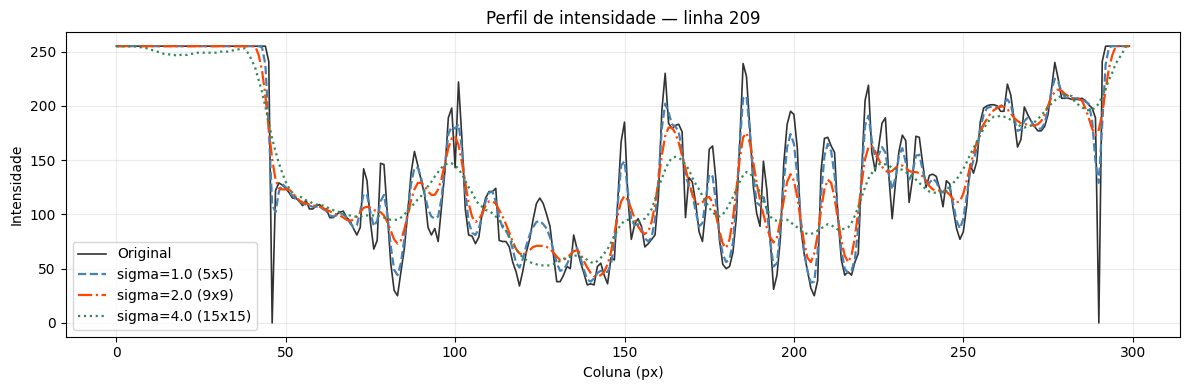

In [20]:
row = img.shape[0] // 2

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(img[row],        color="black",     lw=1.2, alpha=0.8, label="Original")
ax.plot(gauss_1_5[row],  color="steelblue", lw=1.6, ls="--",  label="sigma=1.0 (5x5)")
ax.plot(gauss_2_9[row],  color="orangered", lw=1.6, ls="-.",  label="sigma=2.0 (9x9)")
ax.plot(gauss_4_15[row], color="seagreen",  lw=1.6, ls=":",   label="sigma=4.0 (15x15)")
ax.set_xlabel("Coluna (px)")
ax.set_ylabel("Intensidade")
ax.set_title(f"Perfil de intensidade — linha {row}")
ax.legend(); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()


3)	Aplique o filtro de Mediana para a imagem abaixo, que apresenta um ruído *salt and pepper*
-	3×3 filter;	7×7 filter

In [21]:
from google.colab import files
uploaded = files.upload()
IMAGE_PATH = list(uploaded.keys())[0]


Saving download (3).png to download (3).png


In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


Dimensoes : (418, 320)  |  dtype: uint8


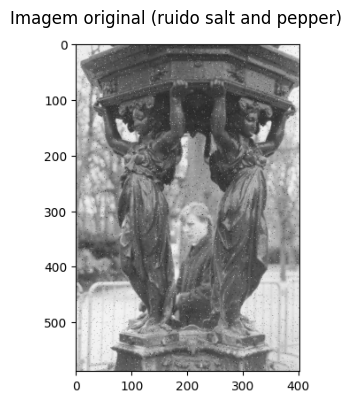

In [23]:
img = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)
print(f"Dimensoes : {img.shape}  |  dtype: {img.dtype}")

plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title("Imagem original (ruido salt and pepper)")
plt.axis("off")
plt.show()


Pixels 'sal'    (255) :  36882  (27.57%)
Pixels 'pimenta'  (0) :   1414  (1.06%)
Total de ruido        :  38296  (28.63%)


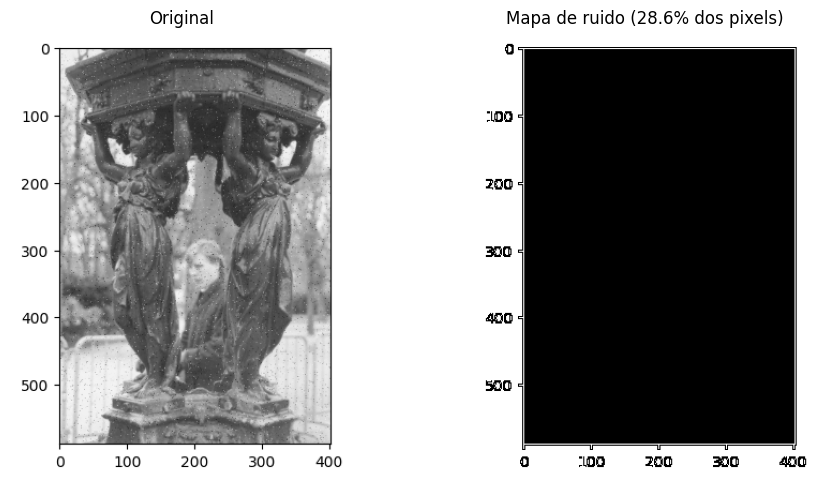

In [24]:
salt    = (img == 255)
pepper  = (img == 0)
total   = img.size

n_salt   = int(salt.sum())
n_pepper = int(pepper.sum())
noise_pct = (n_salt + n_pepper) / total * 100

print(f"Pixels 'sal'    (255) : {n_salt:6d}  ({n_salt/total*100:.2f}%)")
print(f"Pixels 'pimenta'  (0) : {n_pepper:6d}  ({n_pepper/total*100:.2f}%)")
print(f"Total de ruido        : {n_salt+n_pepper:6d}  ({noise_pct:.2f}%)")

noise_map = (salt | pepper).astype(np.uint8) * 255

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img,       cmap="gray"); axes[0].set_title("Original");  axes[0].axis("off")
axes[1].imshow(noise_map, cmap="gray"); axes[1].set_title(f"Mapa de ruido ({noise_pct:.1f}% dos pixels)"); axes[1].axis("off")
plt.tight_layout(); plt.show()


In [25]:
med_3x3 = cv2.medianBlur(img, 3)   # janela 3x3
med_7x7 = cv2.medianBlur(img, 7)   # janela 7x7

for name, filt in [("Mediana 3x3", med_3x3), ("Mediana 7x7", med_7x7)]:
    res_salt   = int((filt == 255).sum())
    res_pepper = int((filt == 0).sum())
    diff_mean  = float(np.abs(img.astype(np.float32) - filt.astype(np.float32)).mean())
    print(f"{name}: sal_residual={res_salt}  pimenta_residual={res_pepper}  diff_media={diff_mean:.2f}")


Mediana 3x3: sal_residual=36838  pimenta_residual=41  diff_media=5.09
Mediana 7x7: sal_residual=37430  pimenta_residual=0  diff_media=9.17


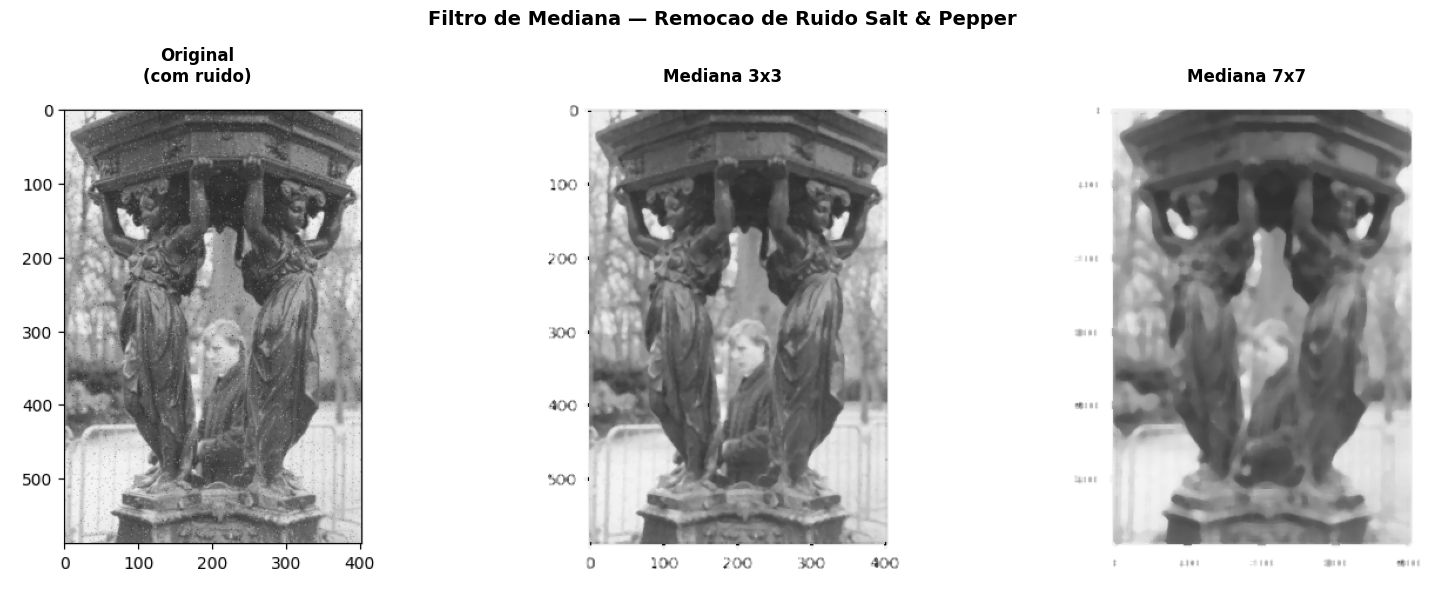

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Filtro de Mediana — Remocao de Ruido Salt & Pepper", fontsize=14, fontweight="bold")

panels = [
    (img,     "Original\n(com ruido)"),
    (med_3x3, "Mediana 3x3"),
    (med_7x7, "Mediana 7x7"),
]

for ax, (data, title) in zip(axes, panels):
    ax.imshow(data, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=8)
    ax.axis("off")

plt.tight_layout()
plt.show()


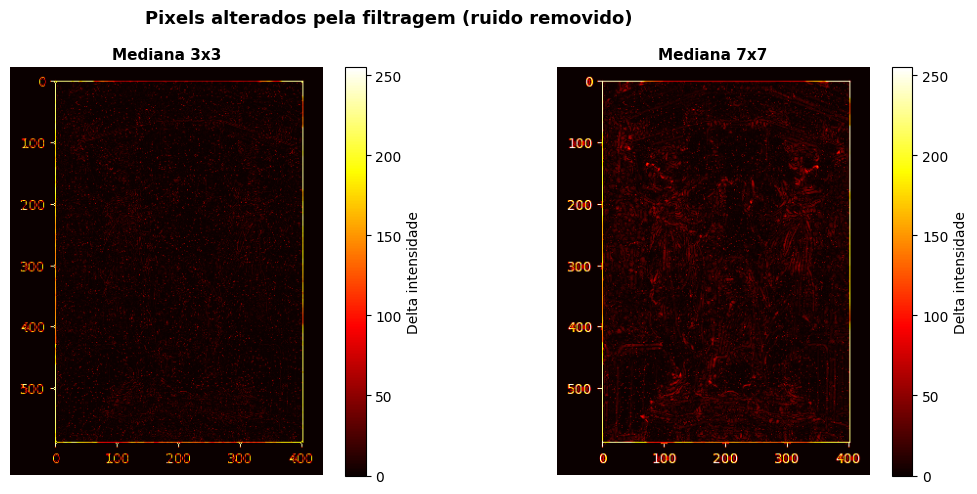

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Pixels alterados pela filtragem (ruido removido)", fontsize=13, fontweight="bold")

for ax, (filt, title) in zip(axes, [(med_3x3, "Mediana 3x3"), (med_7x7, "Mediana 7x7")]):
    diff = np.abs(img.astype(np.float32) - filt.astype(np.float32))
    im   = ax.imshow(diff, cmap="hot", vmin=0)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Delta intensidade")

plt.tight_layout()
plt.show()


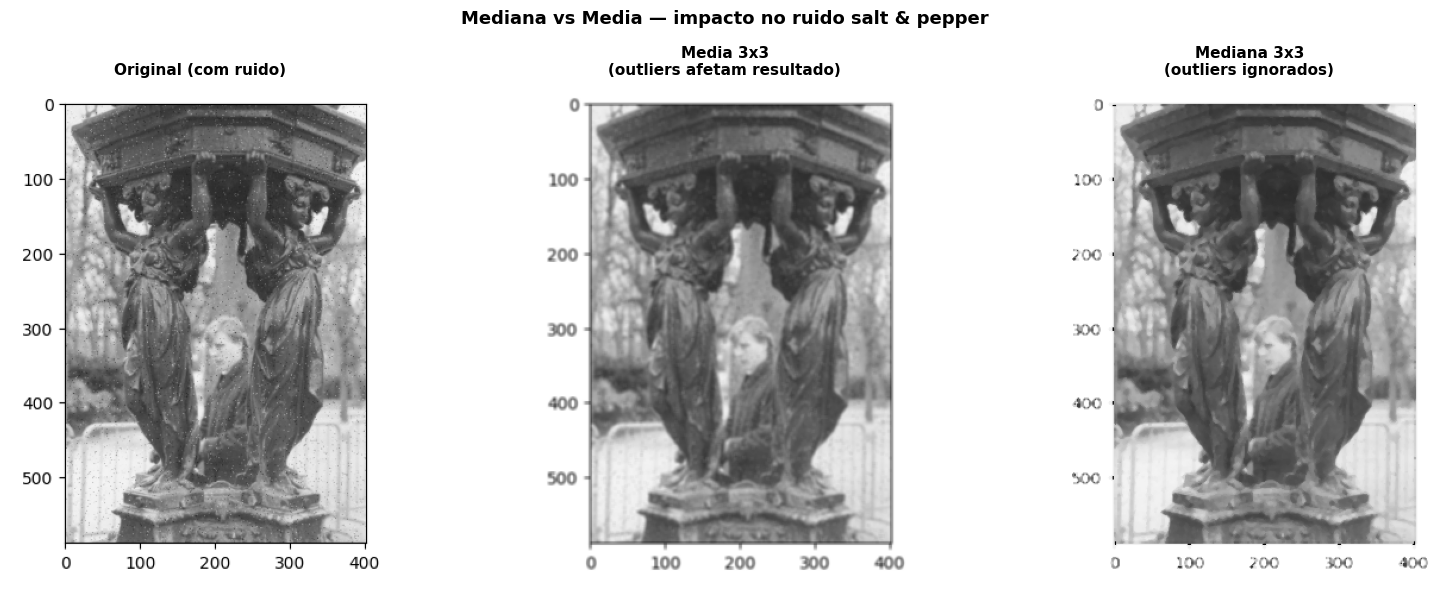

In [28]:
from scipy.ndimage import uniform_filter

mean_3x3 = uniform_filter(img.astype(np.float32), size=3).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Mediana vs Media — impacto no ruido salt & pepper", fontsize=13, fontweight="bold")

for ax, (data, title) in zip(axes, [
    (img,      "Original (com ruido)"),
    (mean_3x3, "Media 3x3\n(outliers afetam resultado)"),
    (med_3x3,  "Mediana 3x3\n(outliers ignorados)"),
]):
    ax.imshow(data, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=8)
    ax.axis("off")

plt.tight_layout()
plt.show()


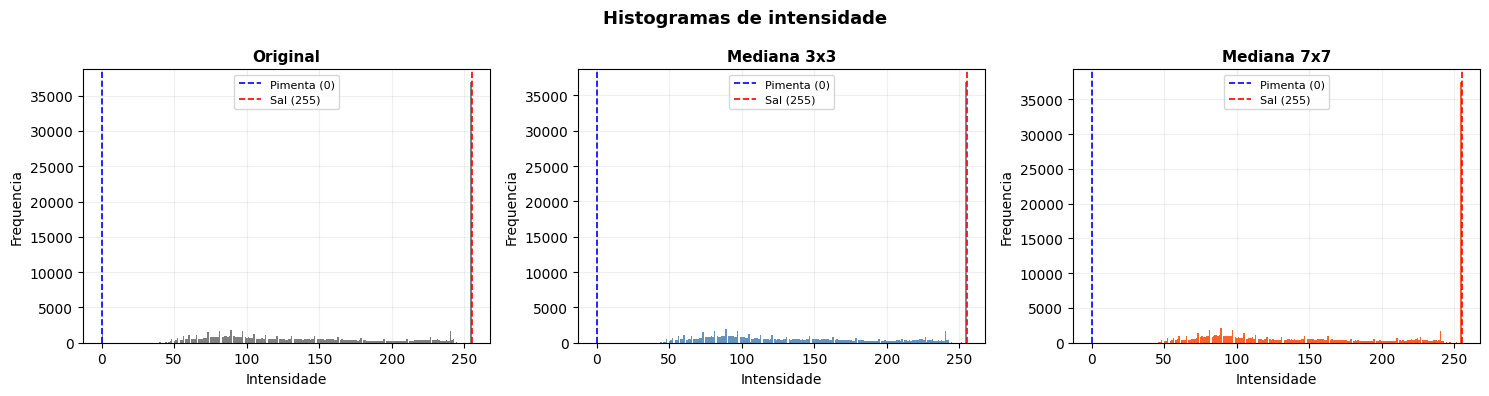

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Histogramas de intensidade", fontsize=13, fontweight="bold")

for ax, (data, title, color) in zip(axes, [
    (img,     "Original",    "dimgray"),
    (med_3x3, "Mediana 3x3", "steelblue"),
    (med_7x7, "Mediana 7x7", "orangered"),
]):
    ax.hist(data.ravel(), bins=256, range=(0,255), color=color, edgecolor="none", alpha=0.85)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Intensidade"); ax.set_ylabel("Frequencia")
    ax.axvline(0,   color="blue",  linestyle="--", linewidth=1.2, label="Pimenta (0)")
    ax.axvline(255, color="red",   linestyle="--", linewidth=1.2, label="Sal (255)")
    ax.legend(fontsize=8); ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


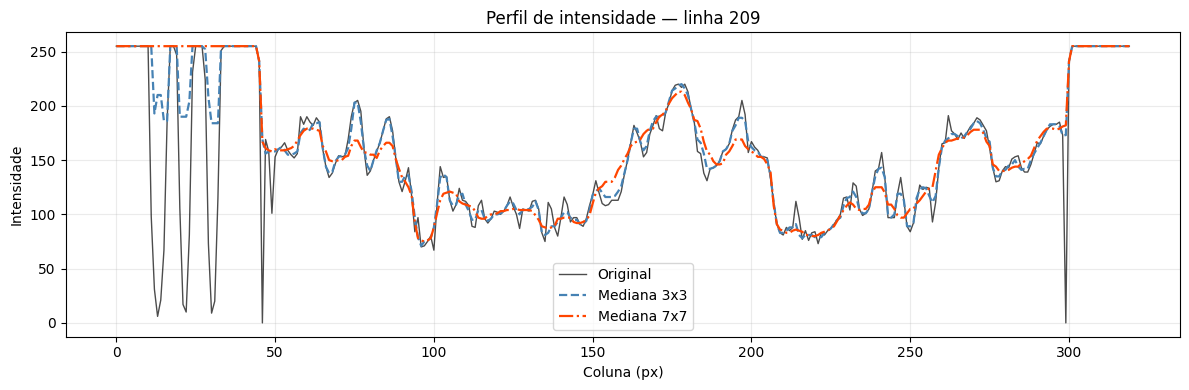

In [30]:
row = img.shape[0] // 2

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(img[row],     color="black",     lw=1.0, alpha=0.7, label="Original")
ax.plot(med_3x3[row], color="steelblue", lw=1.6, ls="--",  label="Mediana 3x3")
ax.plot(med_7x7[row], color="orangered", lw=1.6, ls="-.",  label="Mediana 7x7")
ax.set_xlabel("Coluna (px)"); ax.set_ylabel("Intensidade")
ax.set_title(f"Perfil de intensidade — linha {row}")
ax.legend(); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()


4)	Aplique o filtro de Mediana para a imagem abaixo, que apresenta um ruído salt and pepper. Não utilizar a função pronta do openvc, mas pode usar numpy.median()
- 3×3 filter;	7×7 filter

In [31]:
from google.colab import files
uploaded = files.upload()
IMAGE_PATH = list(uploaded.keys())[0]


Saving download.png to download.png


In [32]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view


Dimensoes : (418, 320)  |  dtype: uint8


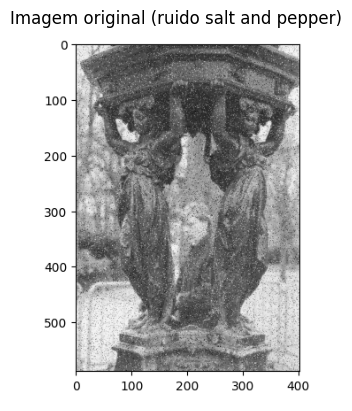

In [33]:
img = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)
print(f"Dimensoes : {img.shape}  |  dtype: {img.dtype}")

plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title("Imagem original (ruido salt and pepper)")
plt.axis("off")
plt.show()


Pixels sal     (255):  36882  (27.57%)
Pixels pimenta   (0):   1414  (1.06%)
Total de ruido      :  38296  (28.63%)


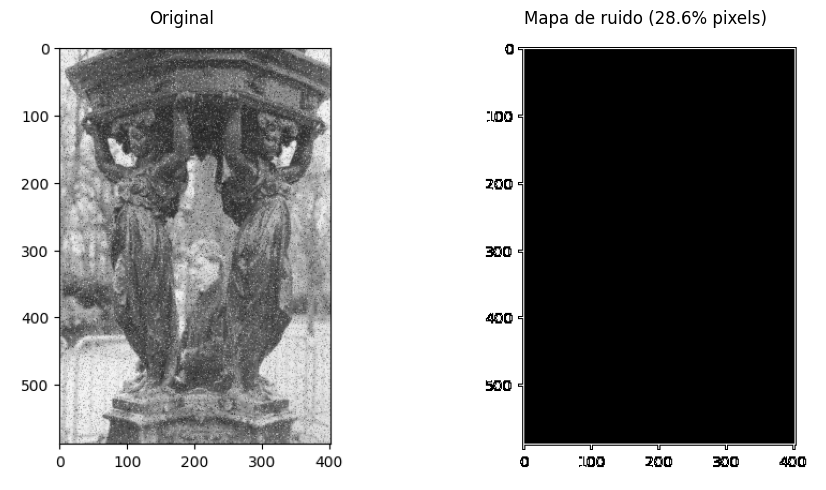

In [34]:
n_salt   = int((img == 255).sum())
n_pepper = int((img == 0).sum())
total    = img.size
pct      = (n_salt + n_pepper) / total * 100

print(f"Pixels sal     (255): {n_salt:6d}  ({n_salt/total*100:.2f}%)")
print(f"Pixels pimenta   (0): {n_pepper:6d}  ({n_pepper/total*100:.2f}%)")
print(f"Total de ruido      : {n_salt+n_pepper:6d}  ({pct:.2f}%)")

noise_map = ((img == 255) | (img == 0)).astype(np.uint8) * 255

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img,       cmap="gray"); axes[0].set_title("Original");                         axes[0].axis("off")
axes[1].imshow(noise_map, cmap="gray"); axes[1].set_title(f"Mapa de ruido ({pct:.1f}% pixels)"); axes[1].axis("off")
plt.tight_layout(); plt.show()


In [35]:
def median_filter(image: np.ndarray, k: int) -> np.ndarray:
    assert k % 2 == 1, "k deve ser impar"
    pad    = k // 2
    padded = np.pad(image.astype(np.float32), pad, mode='edge')

    windows = sliding_window_view(padded, (k, k))

    return np.median(windows, axis=(-2, -1)).astype(np.uint8)


In [36]:
import time

t0 = time.perf_counter()
med_3x3 = median_filter(img, 3)
t1 = time.perf_counter()
med_7x7 = median_filter(img, 7)
t2 = time.perf_counter()

print(f"Mediana 3x3: {(t1-t0)*1000:.1f} ms")
print(f"Mediana 7x7: {(t2-t1)*1000:.1f} ms")

for name, filt in [("Mediana 3x3", med_3x3), ("Mediana 7x7", med_7x7)]:
    res = int(((filt == 0) | (filt == 255)).sum())
    diff_mean = float(np.abs(img.astype(np.float32) - filt.astype(np.float32)).mean())
    print(f"{name}: pixels extremos residuais={res}  diff_media={diff_mean:.2f}")


Mediana 3x3: 27.6 ms
Mediana 7x7: 110.9 ms
Mediana 3x3: pixels extremos residuais=36879  diff_media=8.61
Mediana 7x7: pixels extremos residuais=37430  diff_media=12.40


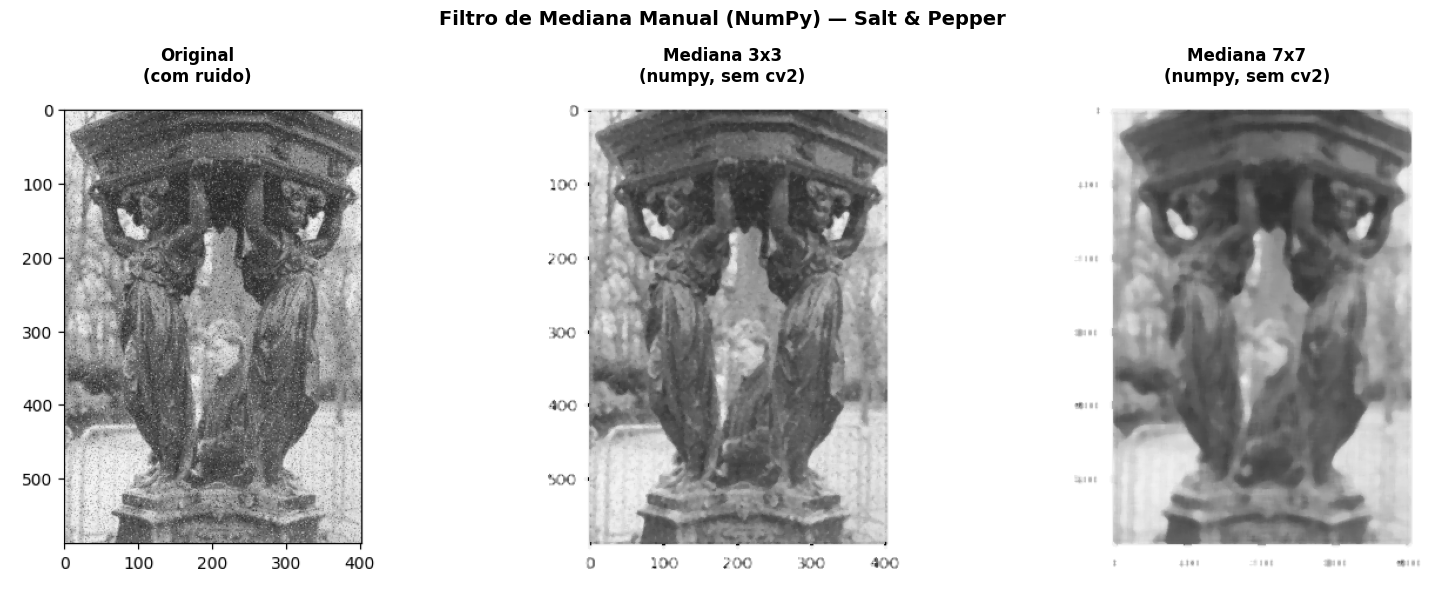

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Filtro de Mediana Manual (NumPy) — Salt & Pepper", fontsize=14, fontweight="bold")

for ax, (data, title) in zip(axes, [
    (img,     "Original\n(com ruido)"),
    (med_3x3, "Mediana 3x3\n(numpy, sem cv2)"),
    (med_7x7, "Mediana 7x7\n(numpy, sem cv2)"),
]):
    ax.imshow(data, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=8)
    ax.axis("off")

plt.tight_layout()
plt.show()


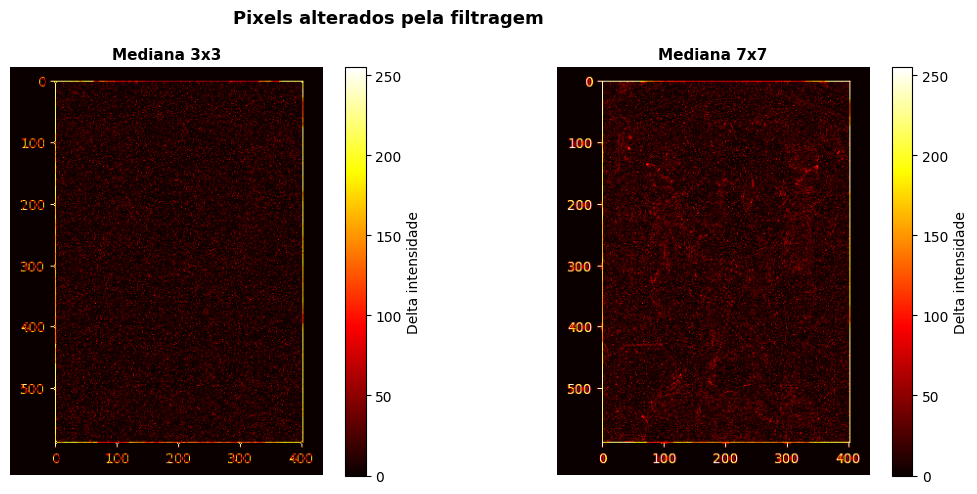

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Pixels alterados pela filtragem", fontsize=13, fontweight="bold")

for ax, (filt, title) in zip(axes, [(med_3x3, "Mediana 3x3"), (med_7x7, "Mediana 7x7")]):
    diff = np.abs(img.astype(np.float32) - filt.astype(np.float32))
    im   = ax.imshow(diff, cmap="hot")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Delta intensidade")

plt.tight_layout()
plt.show()


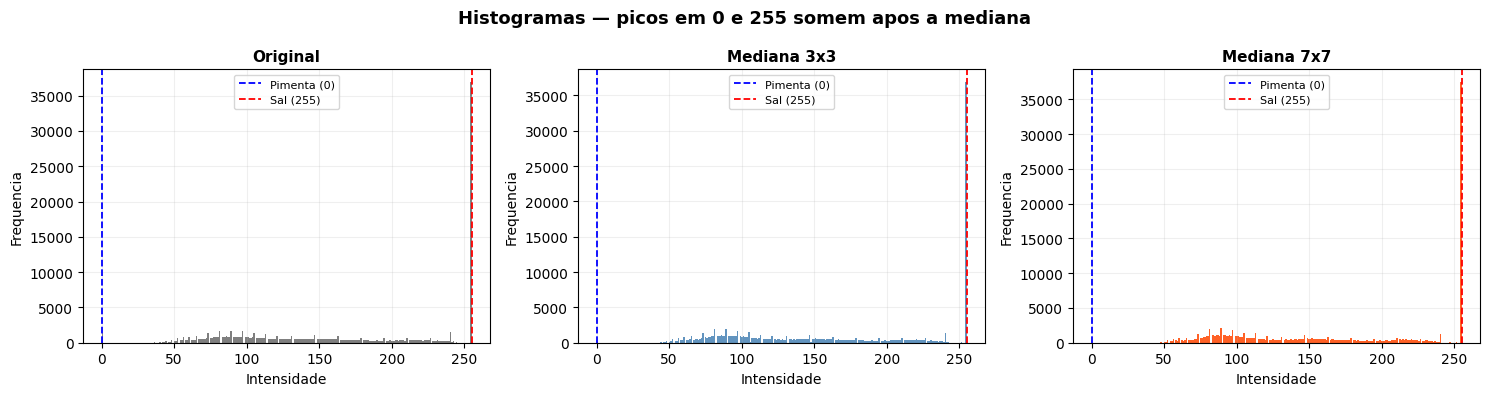

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Histogramas — picos em 0 e 255 somem apos a mediana", fontsize=13, fontweight="bold")

for ax, (data, title, color) in zip(axes, [
    (img,     "Original",    "dimgray"),
    (med_3x3, "Mediana 3x3", "steelblue"),
    (med_7x7, "Mediana 7x7", "orangered"),
]):
    ax.hist(data.ravel(), bins=256, range=(0,255), color=color, edgecolor="none", alpha=0.85)
    ax.axvline(0,   color="blue", ls="--", lw=1.3, label="Pimenta (0)")
    ax.axvline(255, color="red",  ls="--", lw=1.3, label="Sal (255)")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Intensidade"); ax.set_ylabel("Frequencia")
    ax.legend(fontsize=8); ax.grid(alpha=0.2)

plt.tight_layout(); plt.show()


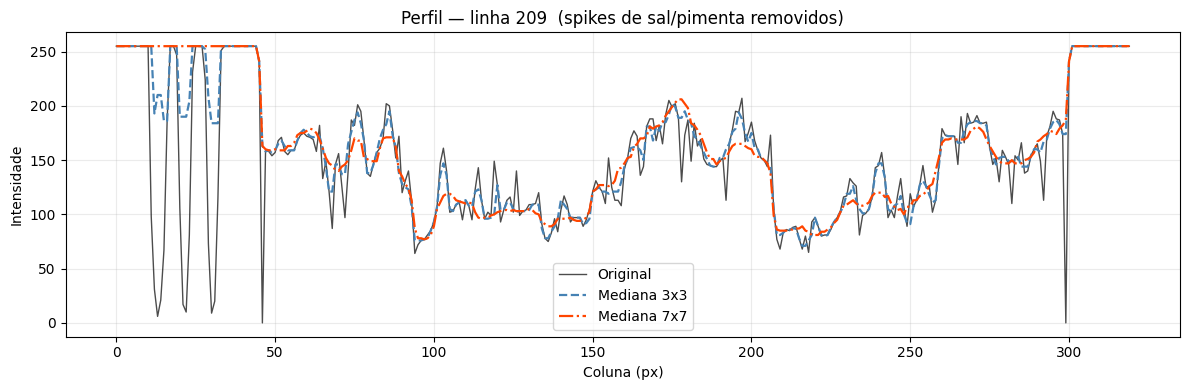

In [40]:
row = img.shape[0] // 2

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(img[row],     color="black",     lw=1.0, alpha=0.7, label="Original")
ax.plot(med_3x3[row], color="steelblue", lw=1.6, ls="--",  label="Mediana 3x3")
ax.plot(med_7x7[row], color="orangered", lw=1.6, ls="-.",  label="Mediana 7x7")
ax.set_xlabel("Coluna (px)"); ax.set_ylabel("Intensidade")
ax.set_title(f"Perfil — linha {row}  (spikes de sal/pimenta removidos)")
ax.legend(); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()
